# Heart Disease EDA - Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Load Data and Basic Statistics](#2-load-data-and-basic-show-statistics)
3. [Data Visualization](#5-data-visualization)
4. [Feature Analysis](#4-feature-analysis)
   - [Binary Variables](#41-binary-variables)
   - [Continuous Variables](#42-continuous-variables)
   - [Quantative Variables](#43-quantative-variables)
5. [Correlation Analysis](#5-correlation-analysis)
6. [Summary and Insights](#6-summary-and-insights)


# 1. Import Libraries

In [1]:
import itertools
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import seaborn as sns
import sys
import os

In [2]:
# Get parent directory
parent_dir = os.path.abspath("..")

# Add to sys.path
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [3]:
from src.preprocess import load_data, split_data

# 2. Load data and Basic show statistics

In [4]:
# Read data
df = load_data()
train_df, _ = split_data(df)
# Show first n rows of data
train_df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
1427,0,53,3.0,1,20.0,0.0,0,0,0,221.0,131.0,89.0,24.09,90.0,95.0,0
3257,0,64,4.0,1,6.0,0.0,0,1,0,239.0,143.0,84.0,20.06,55.0,73.0,0
3822,0,38,3.0,0,0.0,0.0,0,0,0,185.0,100.0,72.0,22.15,85.0,83.0,0
1263,0,49,1.0,0,0.0,0.0,0,0,0,270.0,126.5,67.5,26.56,70.0,77.0,0
3575,1,56,2.0,1,20.0,0.0,0,0,0,186.0,116.0,67.0,24.62,70.0,83.0,0


In [5]:
# Check basic statistics
train_df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3392.000000,3392.000000,3302.000000,3392.000000,3366.000000,3346.000000,3392.000000,3392.000000,3392.000000,3349.000000,3392.000000,3392.000000,3380.000000,3391.000000,3071.000000,3392.000000
mean,0.425413,49.581958,1.967293,0.506191,9.184492,0.031082,0.005601,0.313679,0.027417,237.200657,132.466244,82.993662,25.827550,76.095842,82.135461,0.153597
std,0.494478,8.551839,1.014954,0.500035,11.953730,0.173565,0.074644,0.464056,0.163321,43.807398,22.272675,12.018885,4.122923,11.955496,23.991839,0.360615
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,45.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.060000,68.000000,72.000000,0.000000
50%,0.000000,49.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.350000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,600.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [6]:
# Check inferred data types of each column
train_df.dtypes

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

Looks like education, cigsPerDay and BPMeds unnecessarly is float dtype, can be int

In [7]:
# Find how many unique values are in each column
train_df.nunique()

male                  2
age                  39
education             4
currentSmoker         2
cigsPerDay           33
BPMeds                2
prevalentStroke       2
prevalentHyp          2
diabetes              2
totChol             238
sysBP               227
diaBP               143
BMI                1254
heartRate            70
glucose             137
TenYearCHD            2
dtype: int64

In [8]:
# Number of missing values
train_df.isna().sum(axis=0)

male                 0
age                  0
education           90
currentSmoker        0
cigsPerDay          26
BPMeds              46
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             43
sysBP                0
diaBP                0
BMI                 12
heartRate            1
glucose            321
TenYearCHD           0
dtype: int64

In [9]:
# Check if data is unbalanced
train_df["TenYearCHD"].value_counts()

TenYearCHD
0    2871
1     521
Name: count, dtype: int64

Data is unbalanced

## 2.1. Variables split
<b>Indicators</b>: male, currentSmoker, BPMeds, prevalentStroke, prevalentHyp, diabetes <br>
<b>Categorical</b>: education <br>
<b>Quantitative</b>: age, cigsPerDay, totChol, sysBP, diaBP, BMI, heartRate, glucose <br>
<b>Variable to explain</b>: TenYearCHD


In [10]:
indicators = ["male", "currentSmoker", "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes"]
categorical = ["education", ]
quantative = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]
y = "TenYearCHD"

In [11]:
train_df.fillna(-1, inplace=True)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
1427,0,53,3.0,1,20.0,0.0,0,0,0,221.0,131.0,89.0,24.09,90.0,95.0,0
3257,0,64,4.0,1,6.0,0.0,0,1,0,239.0,143.0,84.0,20.06,55.0,73.0,0
3822,0,38,3.0,0,0.0,0.0,0,0,0,185.0,100.0,72.0,22.15,85.0,83.0,0
1263,0,49,1.0,0,0.0,0.0,0,0,0,270.0,126.5,67.5,26.56,70.0,77.0,0
3575,1,56,2.0,1,20.0,0.0,0,0,0,186.0,116.0,67.0,24.62,70.0,83.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3444,0,36,1.0,1,5.0,0.0,0,1,0,222.0,147.0,94.0,26.79,76.0,71.0,0
466,0,57,3.0,1,15.0,0.0,0,0,0,250.0,125.0,74.0,21.08,80.0,72.0,0
3092,0,60,2.0,0,0.0,0.0,0,1,0,298.0,133.0,89.0,25.09,83.0,81.0,0
3772,1,39,2.0,1,10.0,0.0,0,0,0,215.0,102.0,64.5,24.50,68.0,62.0,0


In [12]:
train_df["BPMeds"] = train_df["BPMeds"].astype(int)

In [13]:
# change columns to categorical for binary and cats
for var in indicators:
    train_df[var] = pd.Categorical(train_df[var])

for var in categorical:
    train_df[var] = pd.Categorical(train_df[var])

# 3. Data Visualization

## 3.1. Univariate analysis

### 3.1.1. Binary

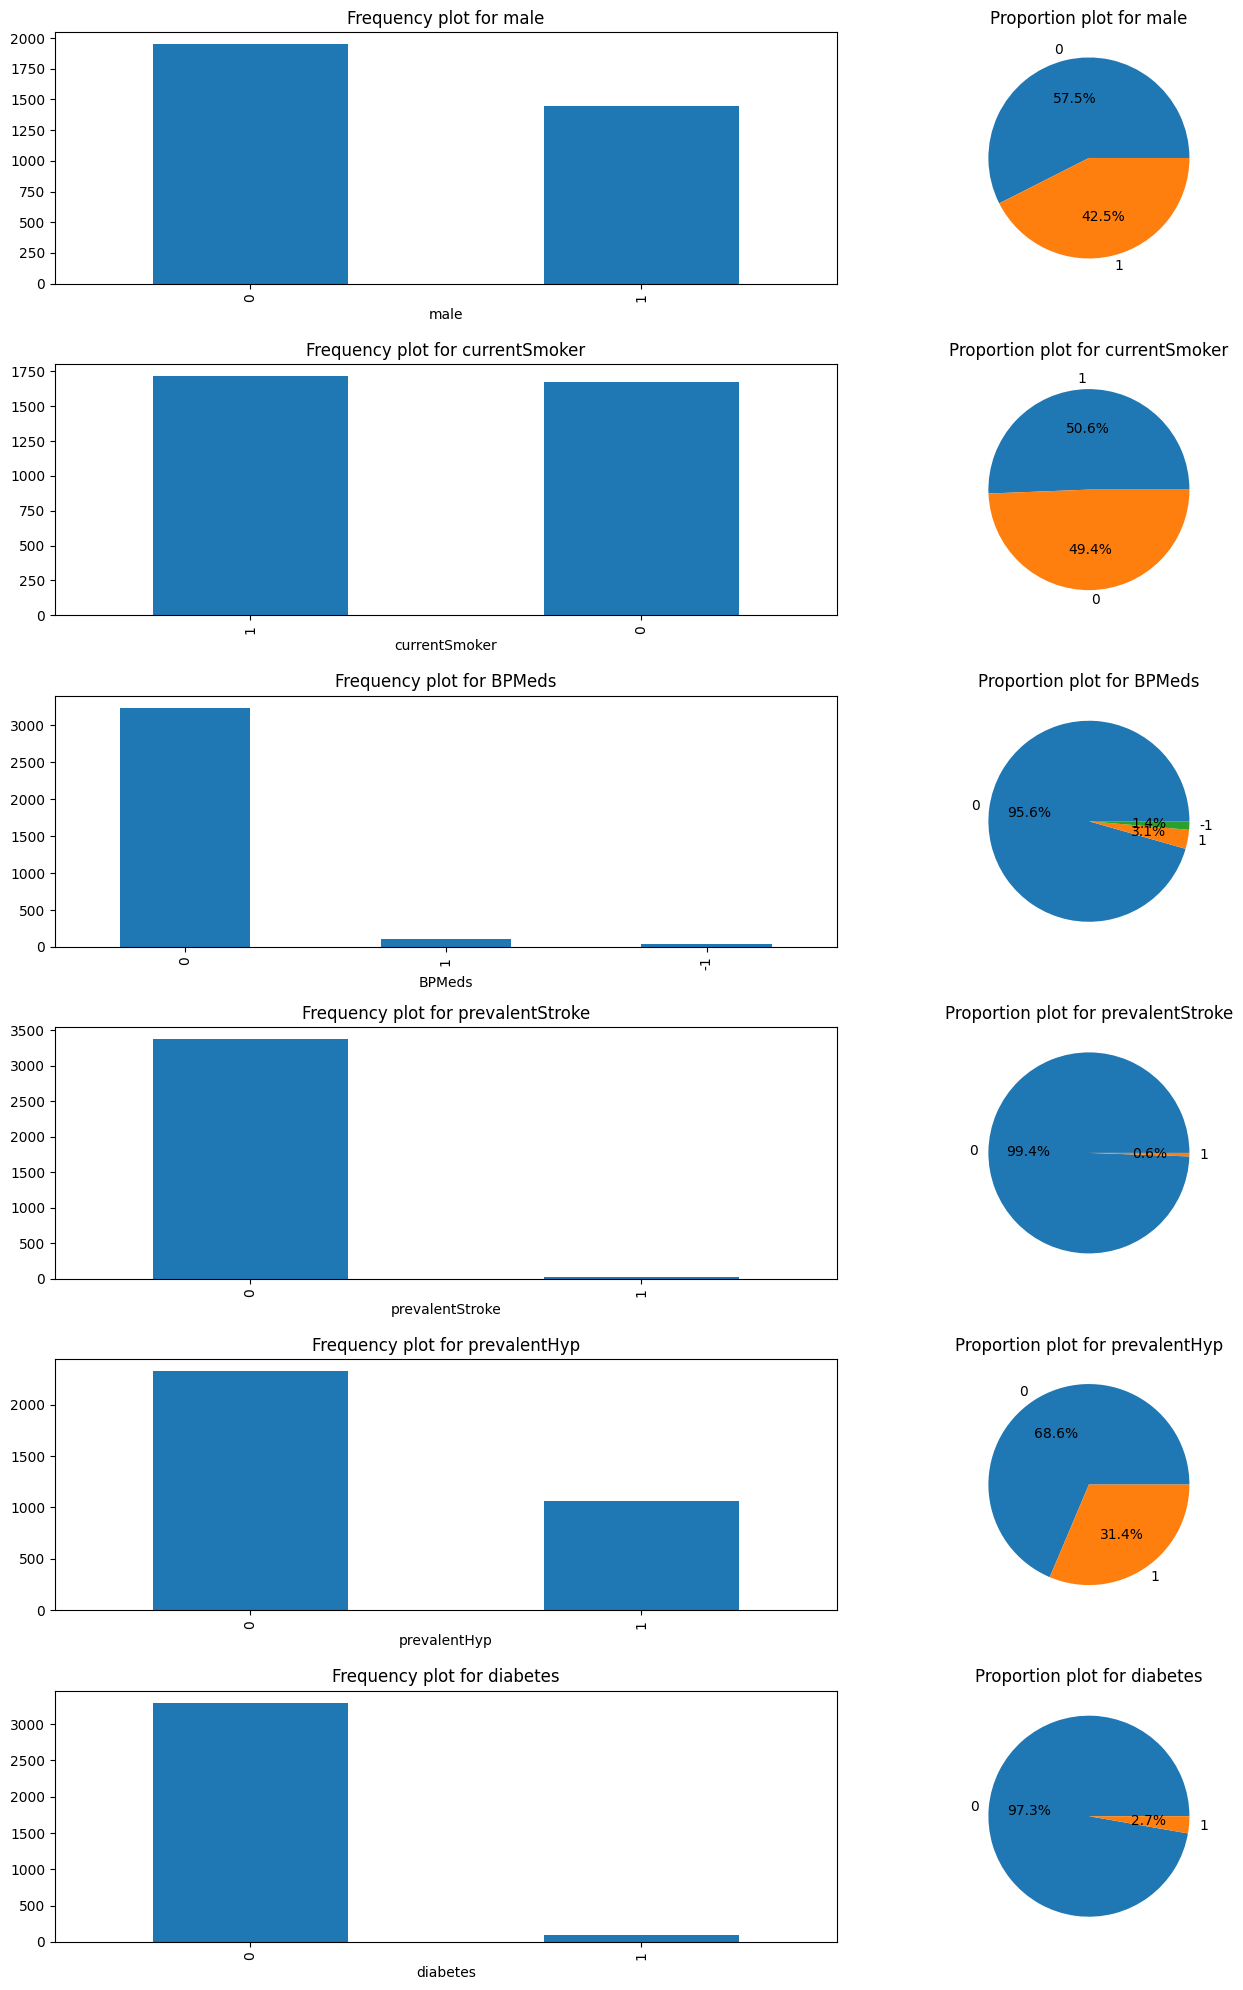

In [14]:
fig, axs = plt.subplots(len(indicators), 2, figsize=(15, 20))
# Binary
for i, var in enumerate(indicators):

    train_df[var].value_counts().plot(kind="bar", ax=axs[i, 0])
    axs[i, 0].set_title(f"Frequency plot for {var}")

    train_df[var].value_counts().plot(kind="pie", ax=axs[i, 1], autopct="%1.1f%%")
    axs[i, 1].set_title(f"Proportion plot for {var}")

plt.tight_layout()
plt.show()

### 3.1.2. Categorical

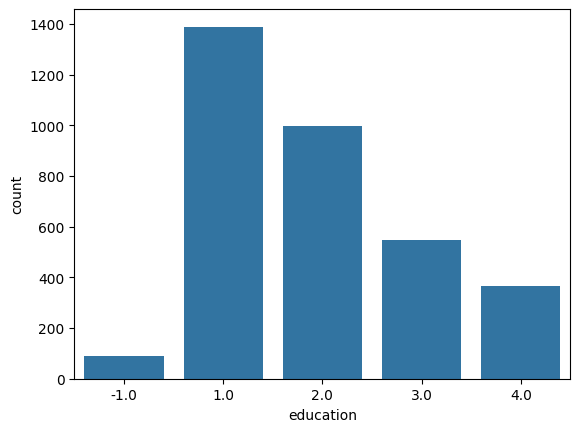

In [15]:
fig, axs = plt.subplots(1, len(categorical))

for i, var in enumerate(categorical):
    sns.countplot(train_df, x=var, ax=axs)

### 3.1.3. Quantitative

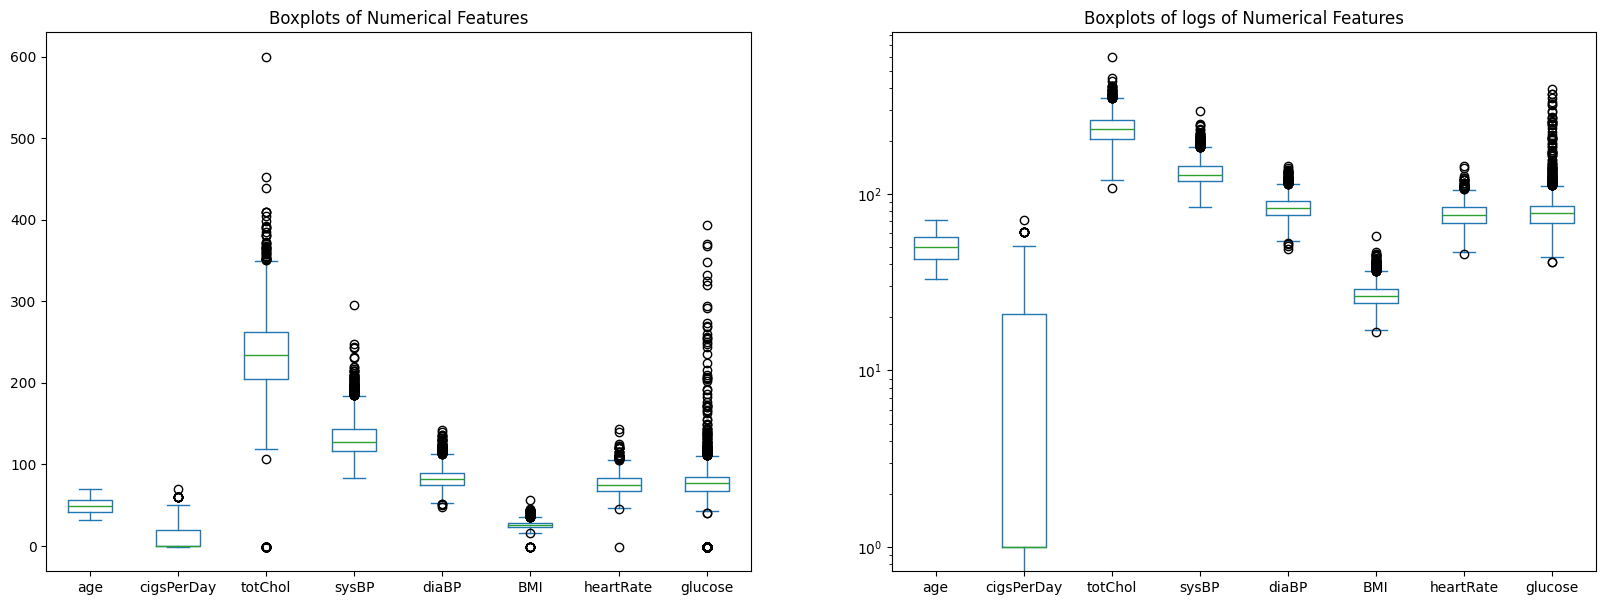

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

train_df[quantative].plot(kind="box", ax=axs[0])
axs[0].set_title("Boxplots of Numerical Features")

(train_df[quantative]+1).plot(kind="box", ax=axs[1], logy=True)
axs[1].set_title("Boxplots of logs of Numerical Features")
plt.show()

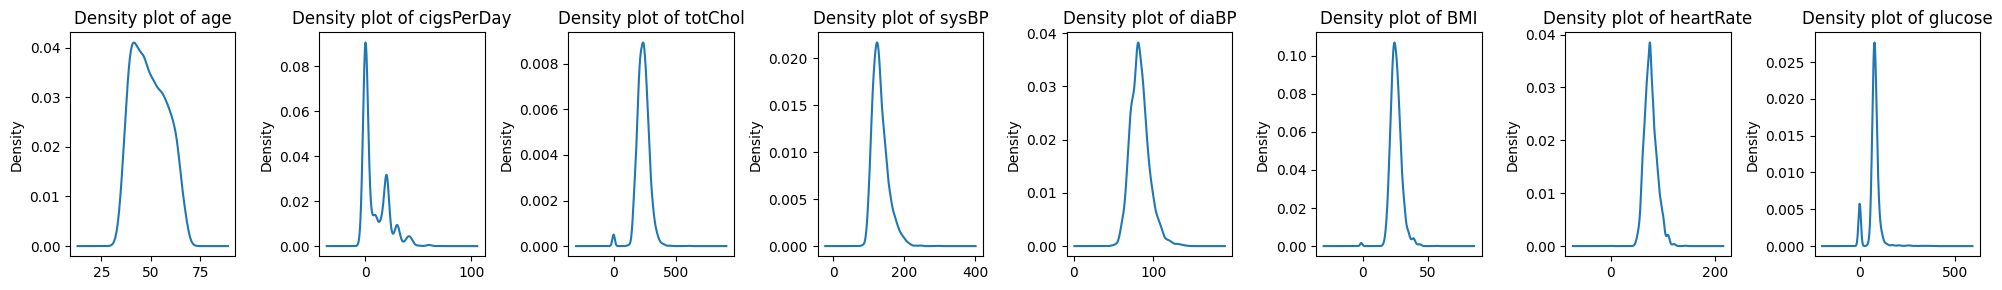

In [17]:
fig, axs = plt.subplots(1, len(quantative), figsize=(20, 3))

for i, var in enumerate(quantative):
    train_df[var].plot(kind="density", ax=axs[i])
    axs[i].set_title(f"Density plot of {var}")
plt.tight_layout()
plt.show()

There are some outliers, especially for measurements

## 3.2. Bivariate

### 3.2.1. Quantitative vs quantitative

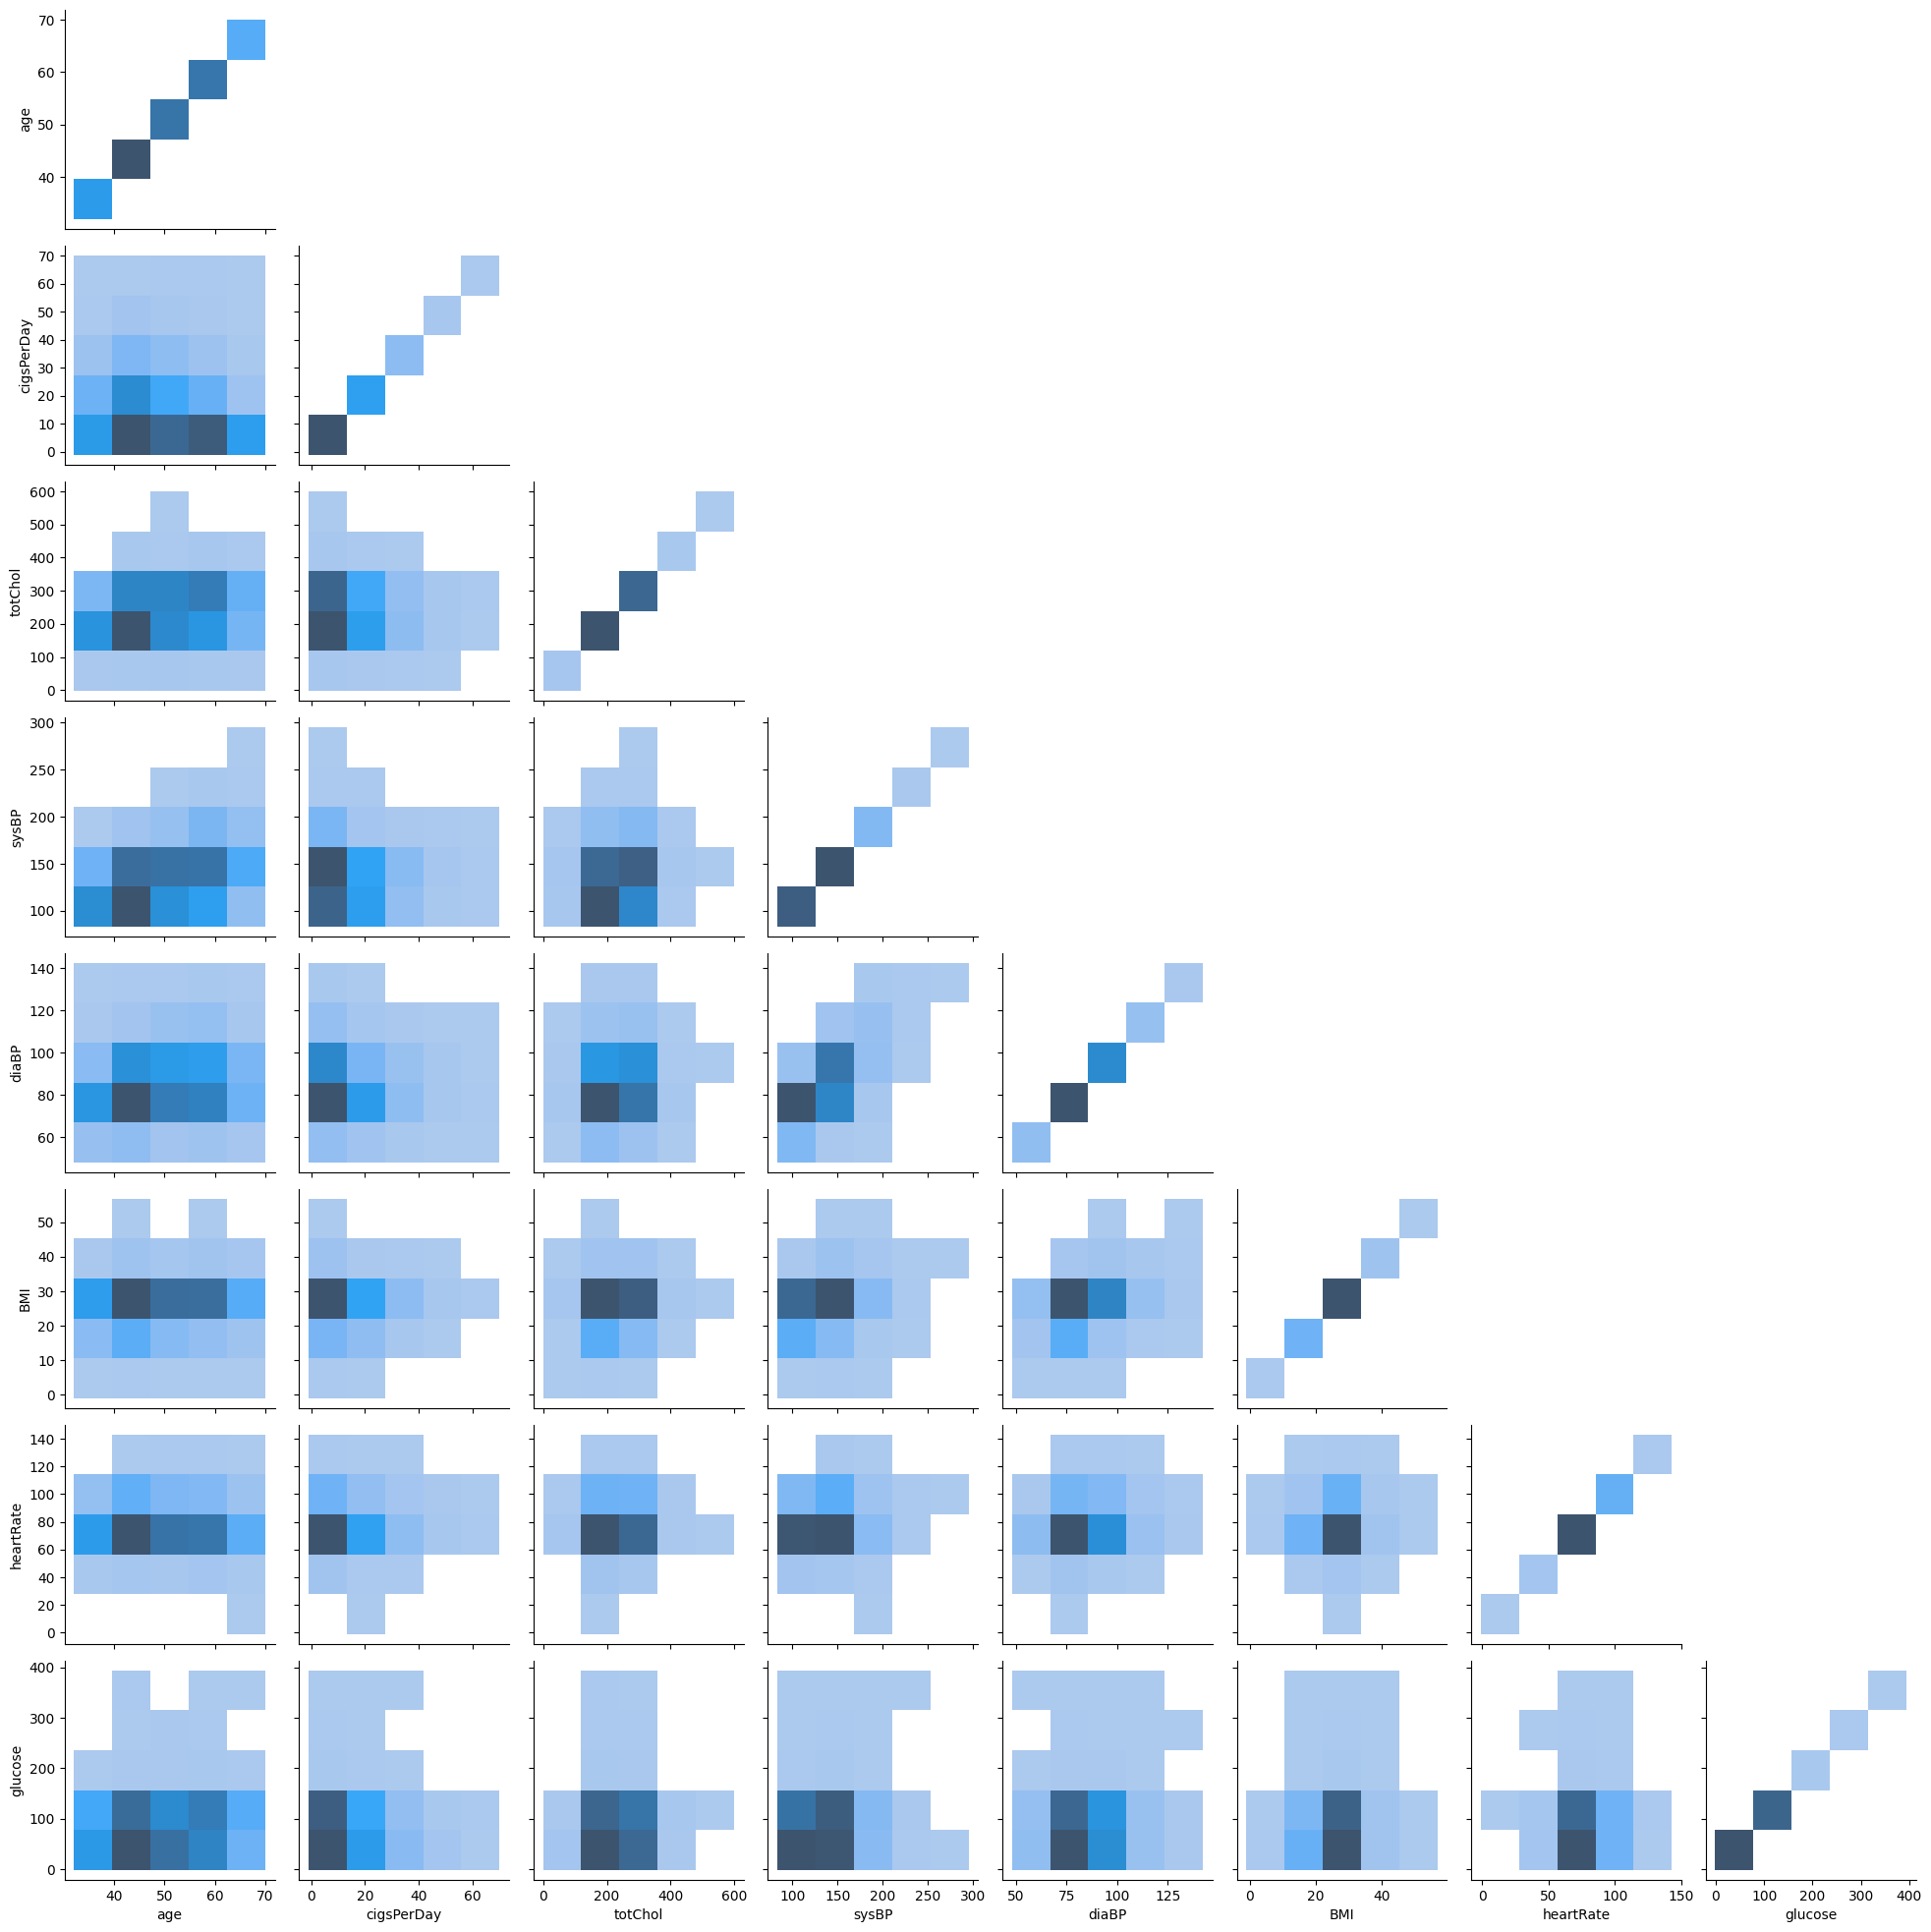

In [18]:
sns.pairplot(train_df[quantative], kind="hist", diag_kind=None, corner=True, plot_kws=dict(bins=5))

### 3.2.2. Binary and categorical vs binary and categorical

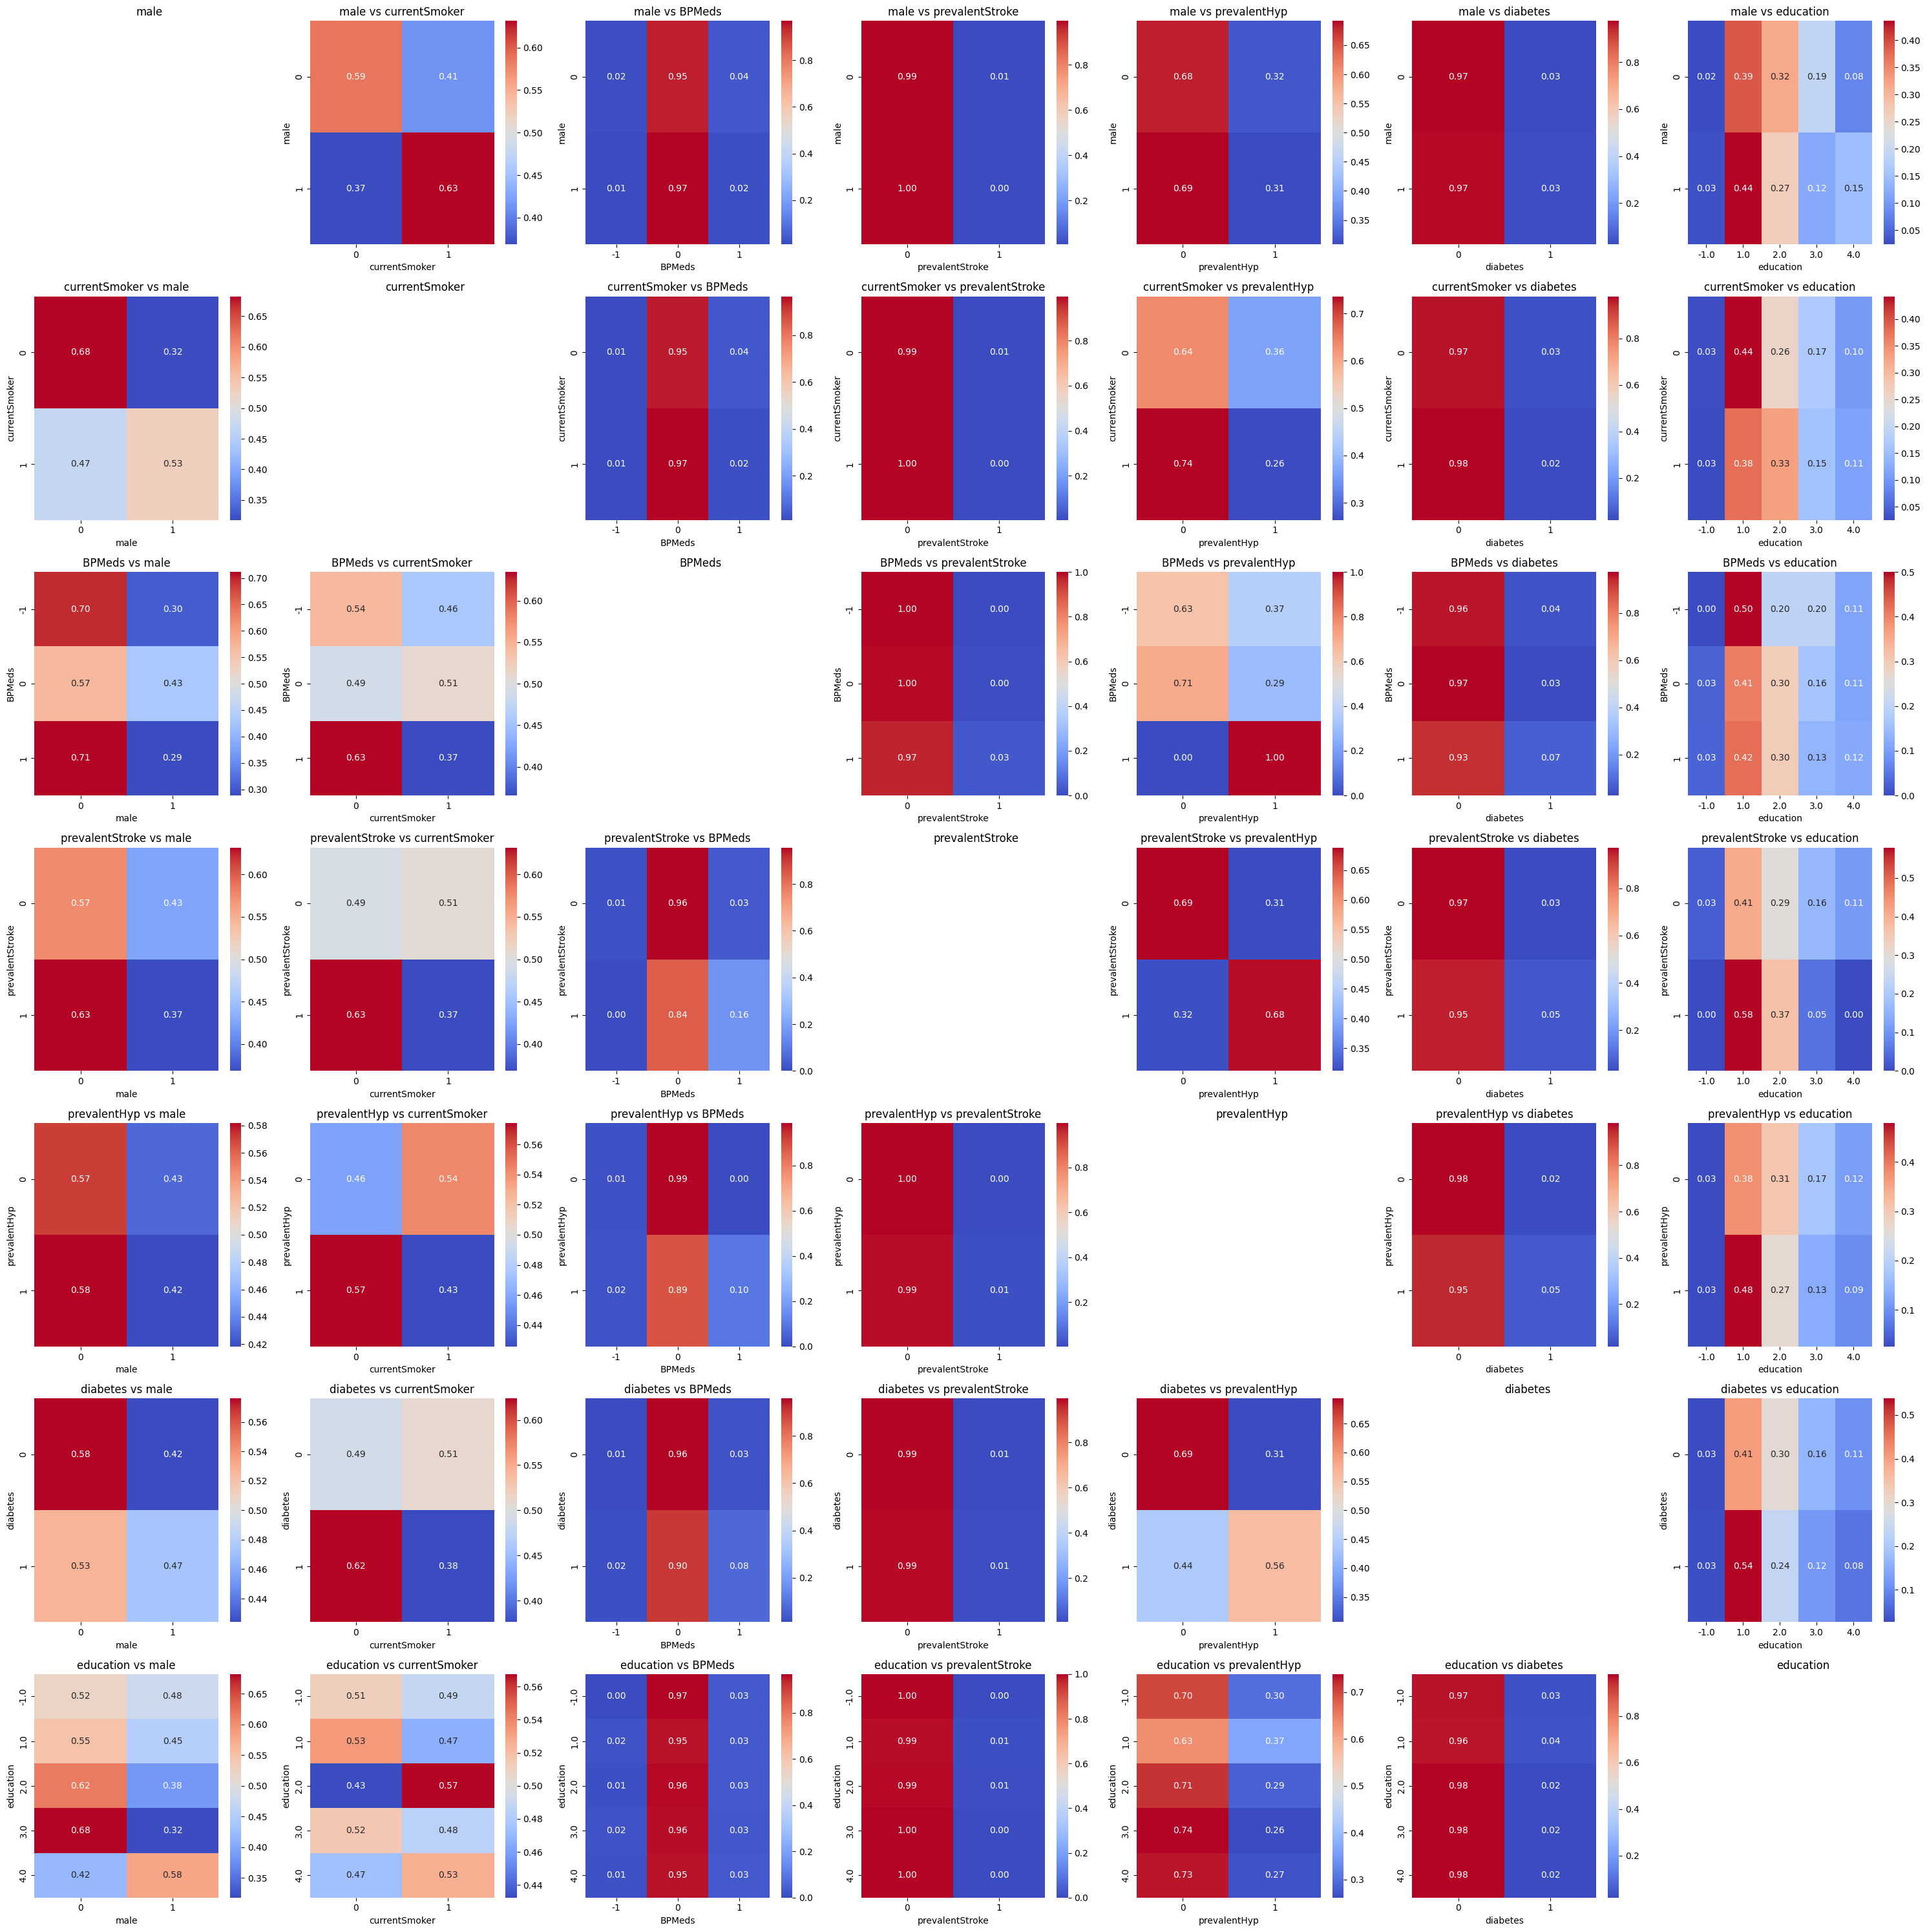

In [19]:
fig, axs = plt.subplots(len(indicators + categorical), len(indicators + categorical), figsize=(30, 30))

for i1, col1 in enumerate(indicators + categorical):
    for i2, col2 in enumerate(indicators + categorical):
        if i1 == i2:
            axs[i1, i2].axis("off")
            axs[i1, i2].set_title(f"{col1}")
        else:
            ct = pd.crosstab(train_df[col1], train_df[col2], normalize="index")
            sns.heatmap(ct, annot=True, fmt='.2f', cmap='coolwarm', ax=axs[i1, i2])
            axs[i1, i2].set_title(f'{col1} vs {col2}')
            axs[i1, i2].set_xlabel(col2)
            axs[i1, i2].set_ylabel(col1)


plt.tight_layout()
plt.show()


### 3.2.3. Binary vs numerical

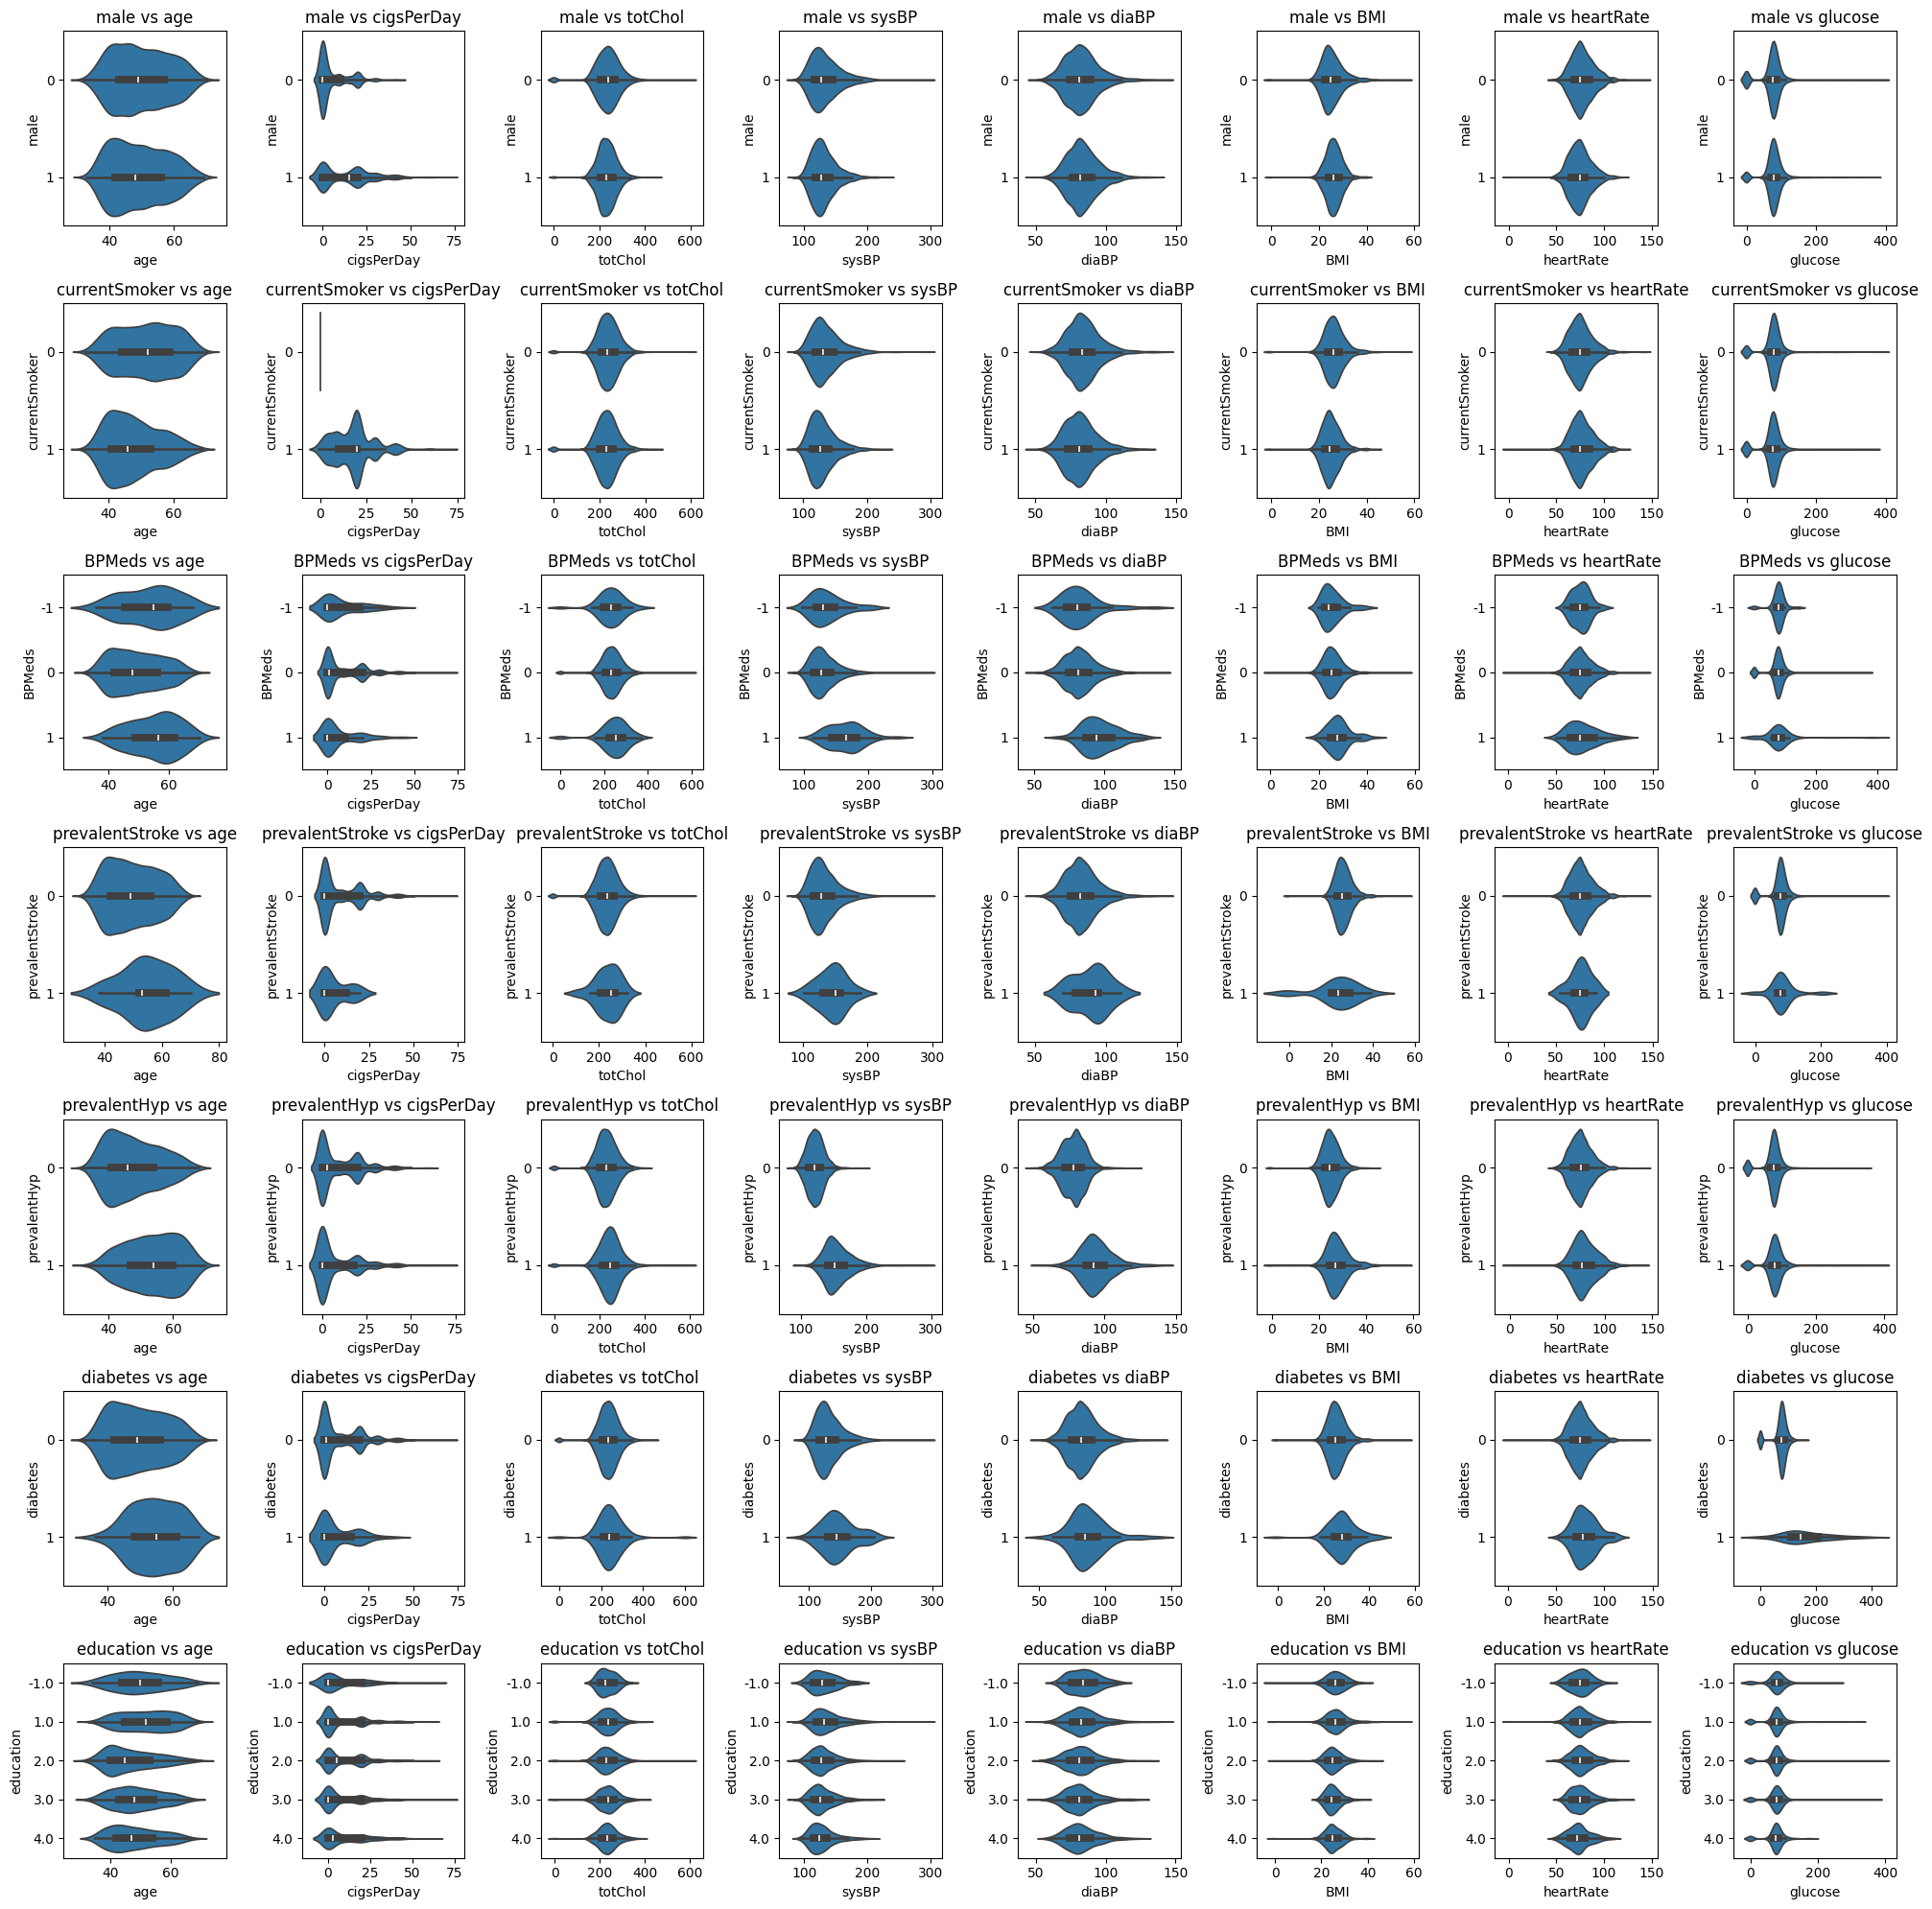

In [20]:
fig, axs = plt.subplots(len(indicators + categorical), len(quantative), figsize=(20, 20))

for i1, col1 in enumerate(indicators + categorical):
    for i2, col2 in enumerate(quantative):
        sns.violinplot(data=train_df, y=col1, x=col2, ax=axs[i1, i2])
        axs[i1, i2].set_title(f'{col1} vs {col2}')

plt.tight_layout()
plt.show()

# 4. Feature analysis

## 4.1. Binary variables

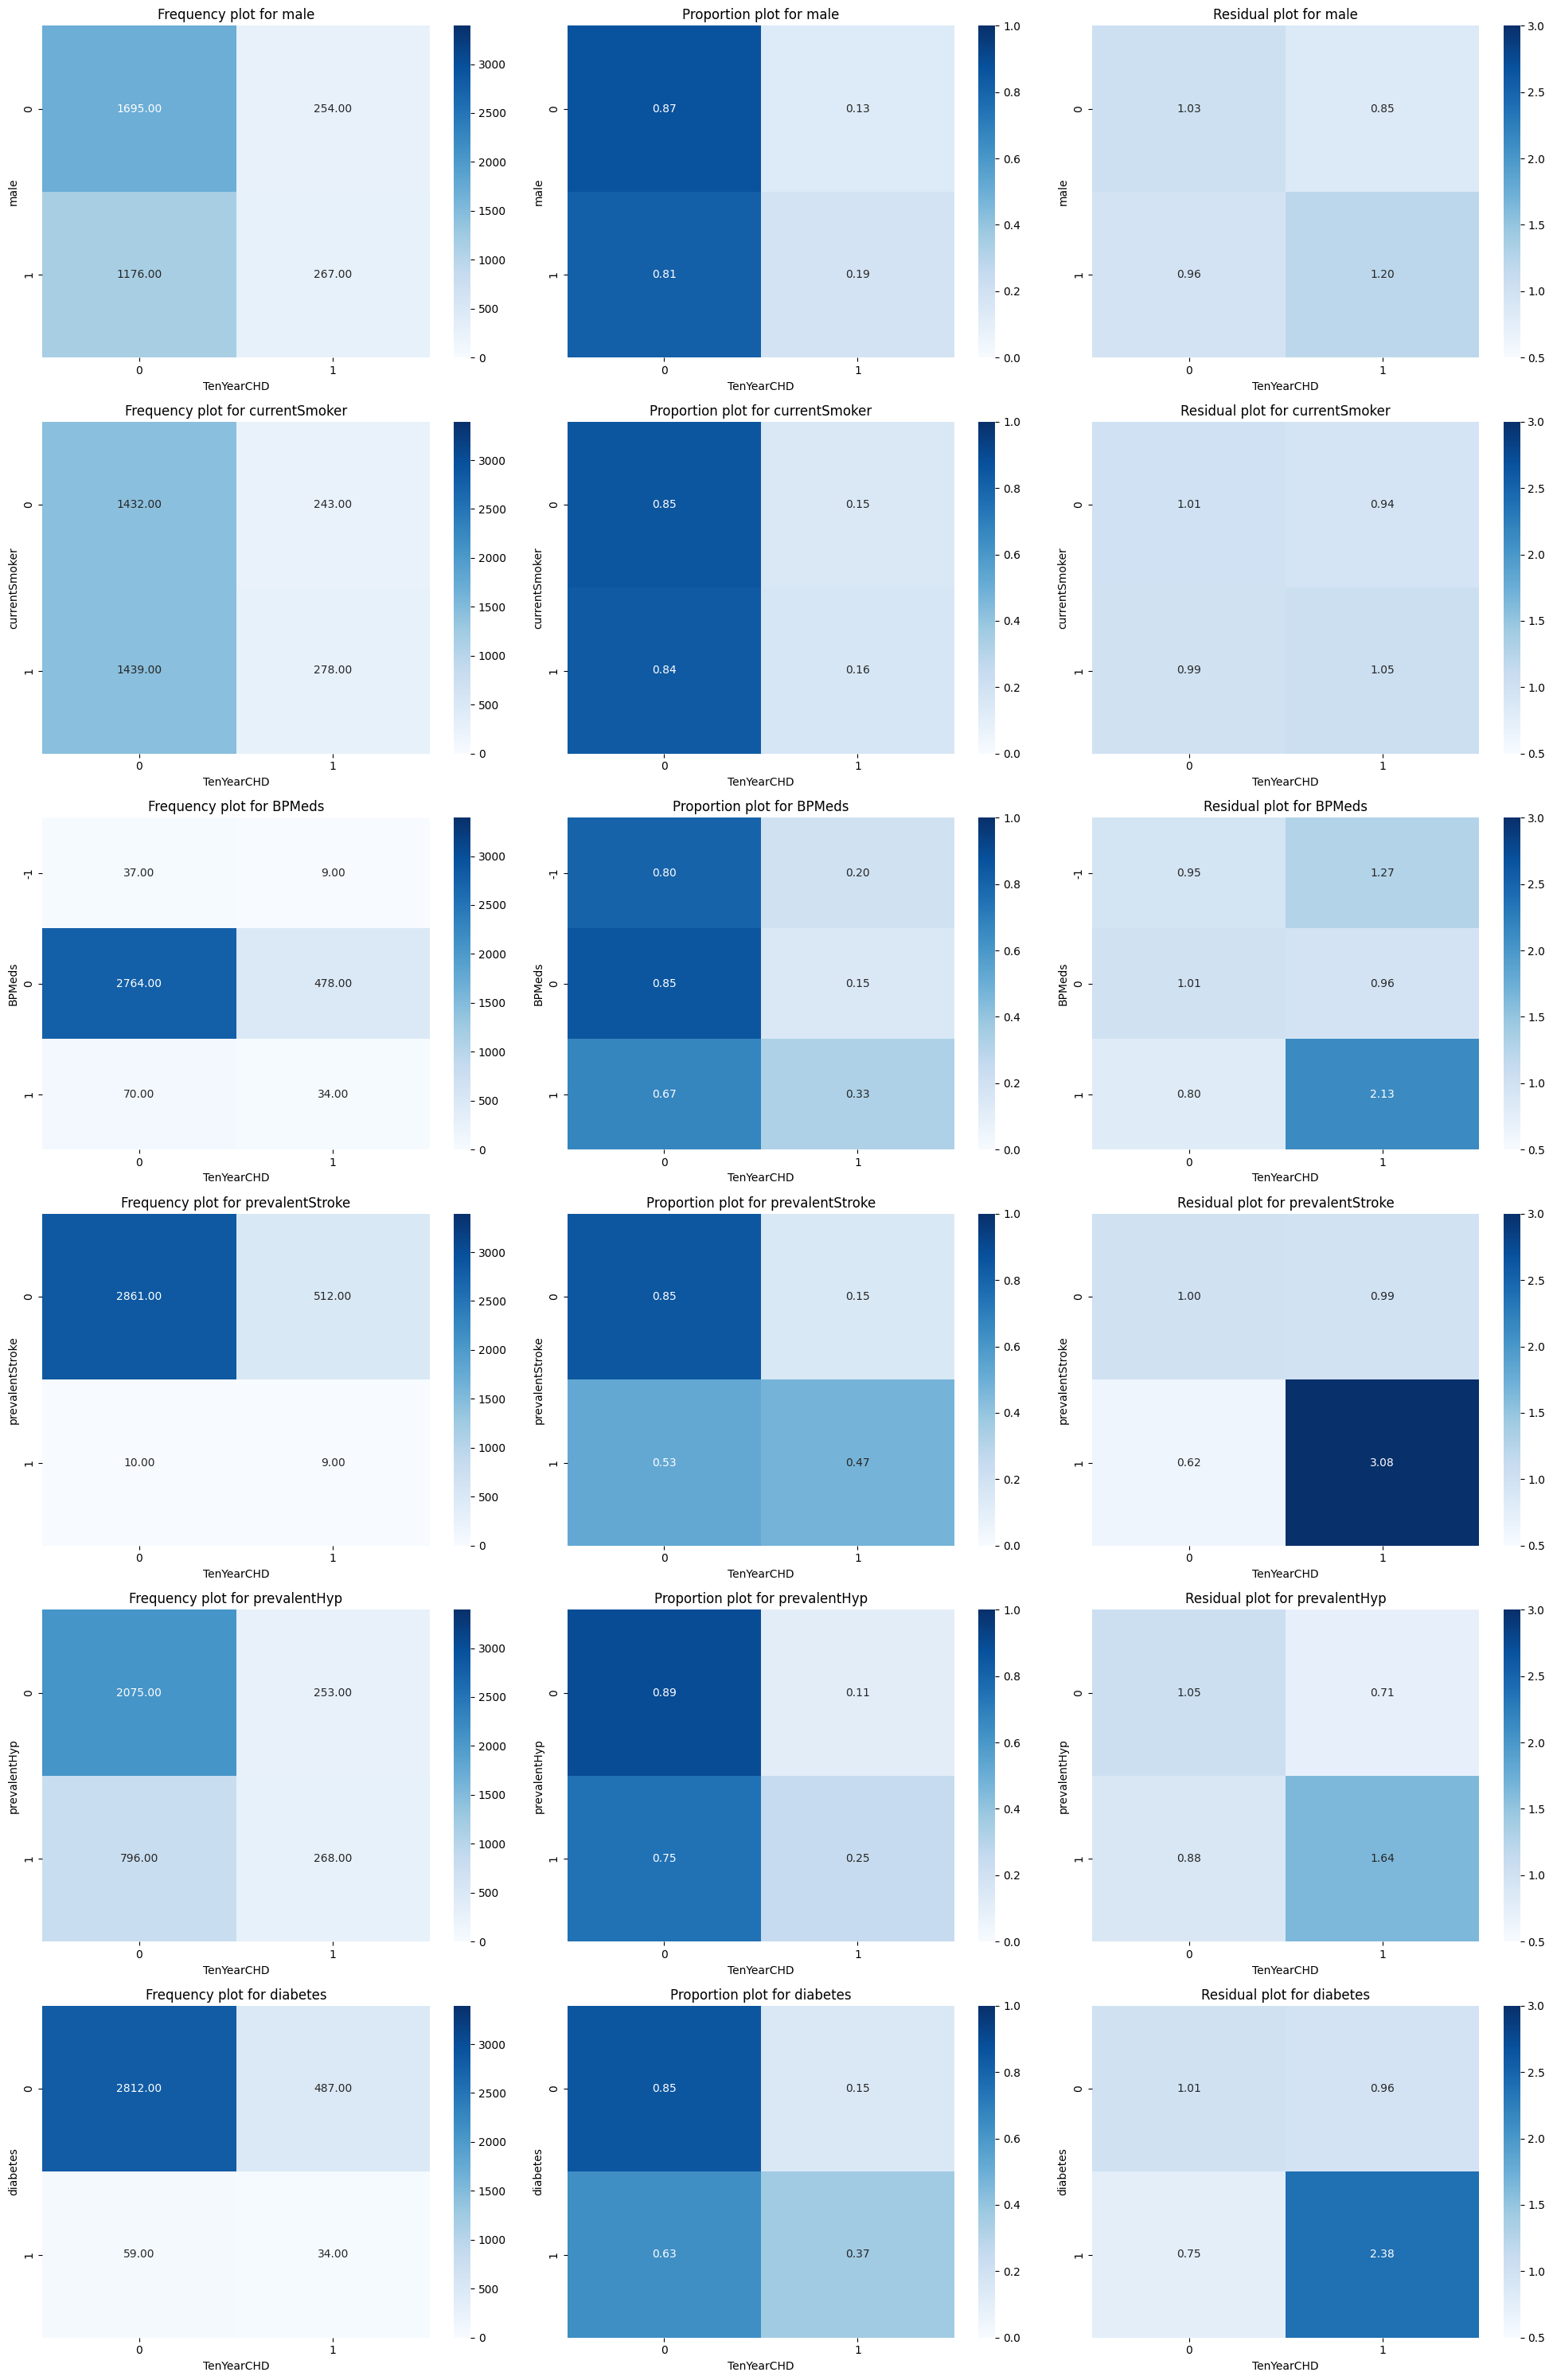

In [21]:
fig, axs = plt.subplots(len(indicators), 3, figsize=(20, 30))
count_norm = mcolors.Normalize(vmin=0, vmax=len(train_df))
res_norm = mcolors.Normalize(vmin=0.5, vmax=3.)

for i, var in enumerate(indicators):
    ct = pd.crosstab(train_df[var], train_df[y])
    sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", norm=count_norm, cbar=True, ax=axs[i,0])
    axs[i, 0].set_title(f"Frequency plot for {var}")

    ct = pd.crosstab(train_df[var], train_df[y], normalize="index")
    sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", cbar=True, ax=axs[i,1], vmin=0, vmax=1)
    axs[i, 1].set_title(f"Proportion plot for {var}")

    ct = pd.crosstab(train_df[var], train_df[y], normalize=True)
    expected = np.outer(ct.sum(axis=1), ct.sum(axis=0))
    sns.heatmap(ct / expected, annot=True, fmt=".2f", cmap="Blues", norm=res_norm, cbar=True, ax=axs[i,2])
    axs[i, 2].set_title(f"Residual plot for {var}")

plt.tight_layout()
plt.show()

You can see strong correlations for some values like: <br>
<ul>
    <li>males are slightly more prone to heart diseases than females</li>
    <li>no differentiation between smokers and non-smokers</li>
    <li>BPMeds two times more probable than no</li>
    <li>People after stroke have heart diseases 3 times more often than the ones how did not have it before</li>
    <li>prevalentHyp small dependency</li>
    <li>diabetes - significant</li>
</ul>
<h4>Summary for binary</h4>
1. Variables to include: BPMeds, prevalentStroke, diabetes <br>
2. Possible impact: prevalentHyp, male

Also worth checking correlations between those variables.

## 4.2. Categorical variables

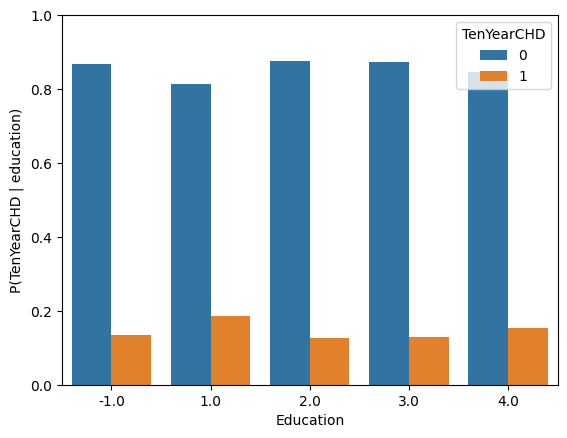

In [22]:
ct = pd.crosstab(train_df["education"], train_df[y], normalize="index")
plot_df = (
    ct
    .reset_index()
    .melt(
        id_vars="education",
        value_vars=[0, 1],
        var_name="TenYearCHD",
        value_name="probability"
    )
)
sns.barplot(
    data=plot_df,
    x="education",
    y="probability",
    hue="TenYearCHD"
)

plt.ylim(0, 1)
plt.ylabel("P(TenYearCHD | education)")
plt.xlabel("Education")
plt.show()

Slightly higher probability of disease for 1 and 4. <br>
Worth checking interactions with other variables

## 4.3. Quantative variables

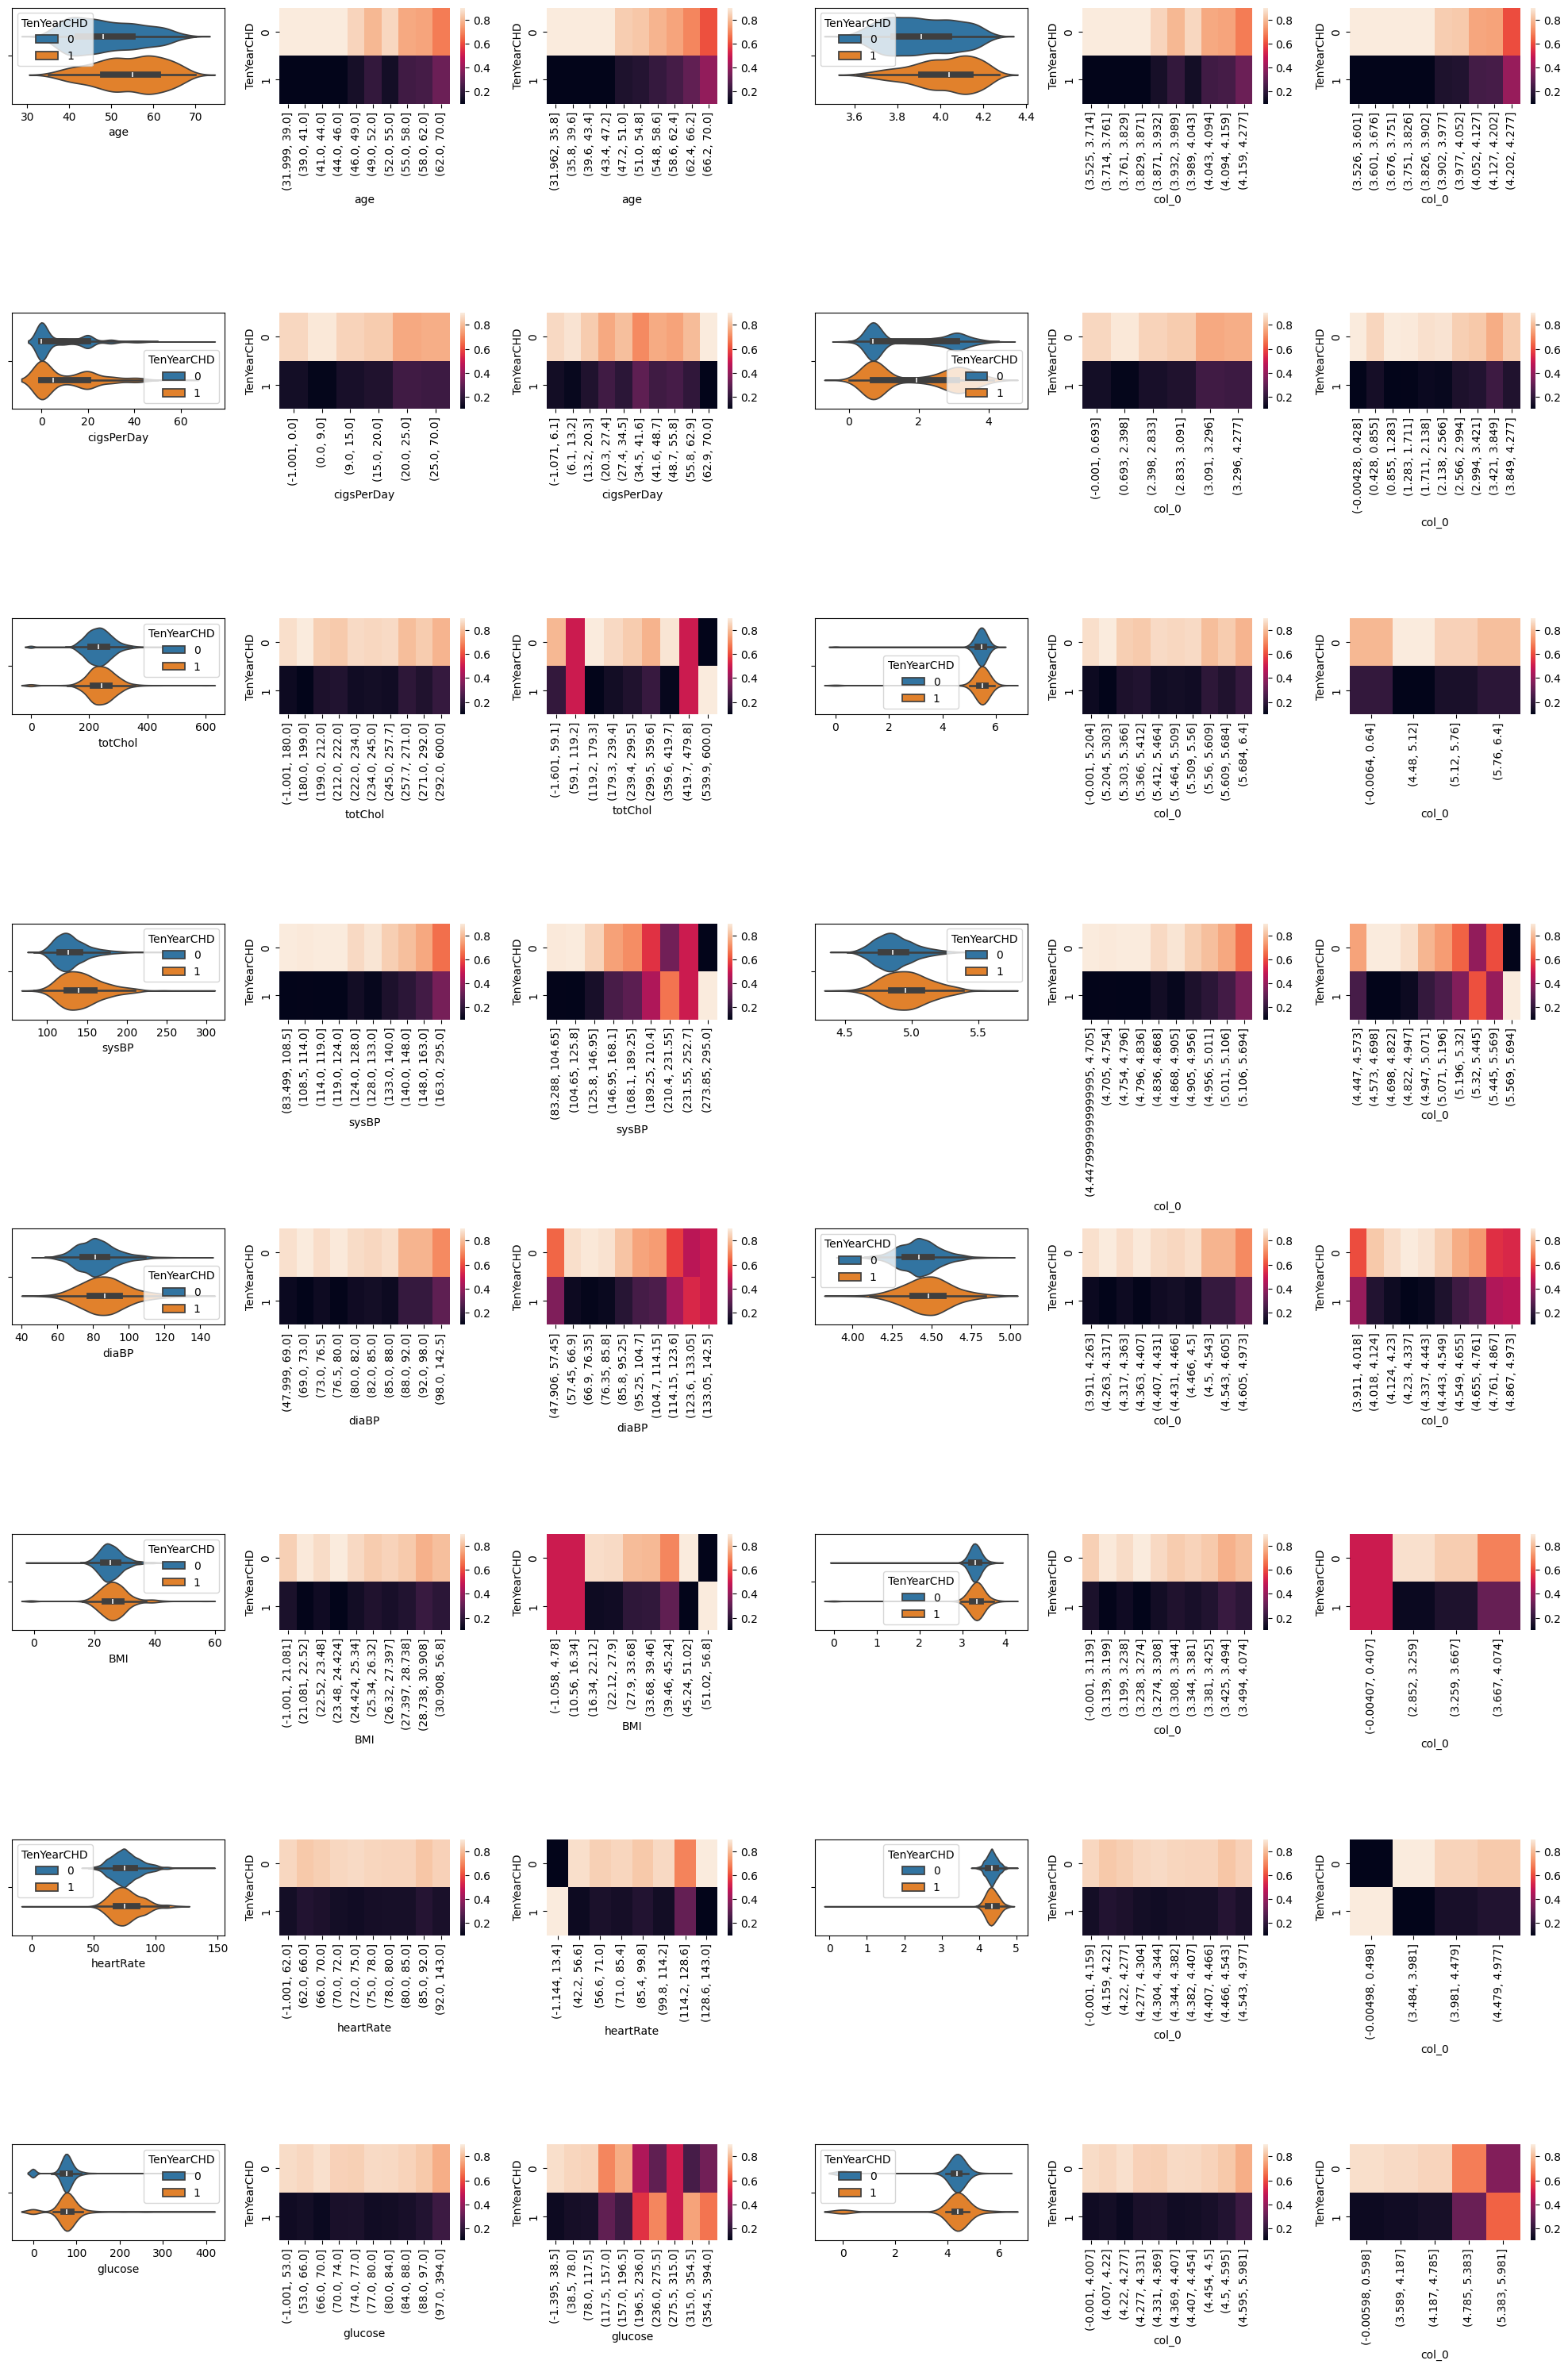

In [23]:
fig, axs = plt.subplots(len(quantative), 6, figsize=(20, 30))
for i, var in enumerate(quantative):
    sns.violinplot(train_df, x=var, hue=y, ax=axs[i, 0])

    sns.heatmap(pd.crosstab(train_df[y], pd.qcut(train_df[var], 10, duplicates="drop"), normalize="columns"), vmin=0.1, vmax=0.9, ax=axs[i, 1])

    sns.heatmap(pd.crosstab(train_df[y], pd.cut(train_df[var], 10, duplicates="drop"), normalize="columns"), vmin=0.1, vmax=0.9, ax=axs[i, 2])

    dt = np.nan_to_num(np.log1p(train_df[var] + 1))
    sns.violinplot(x=dt, hue=train_df[y], ax=axs[i, 3])

    sns.heatmap(pd.crosstab(train_df[y], pd.qcut(dt, 10, duplicates="drop"), normalize="columns"), vmin=0.1, vmax=0.9, ax=axs[i, 4])

    sns.heatmap(pd.crosstab(train_df[y], pd.cut(dt, 10, duplicates="drop"), normalize="columns"), vmin=0.1, vmax=0.9, ax=axs[i, 5])

plt.tight_layout()
plt.show()

Not seen any material impacts.<br>
Small impact for higher BMI, biaBP, sysBP and ages

# 5. Correlation analysis

<Figure size 1000x800 with 0 Axes>

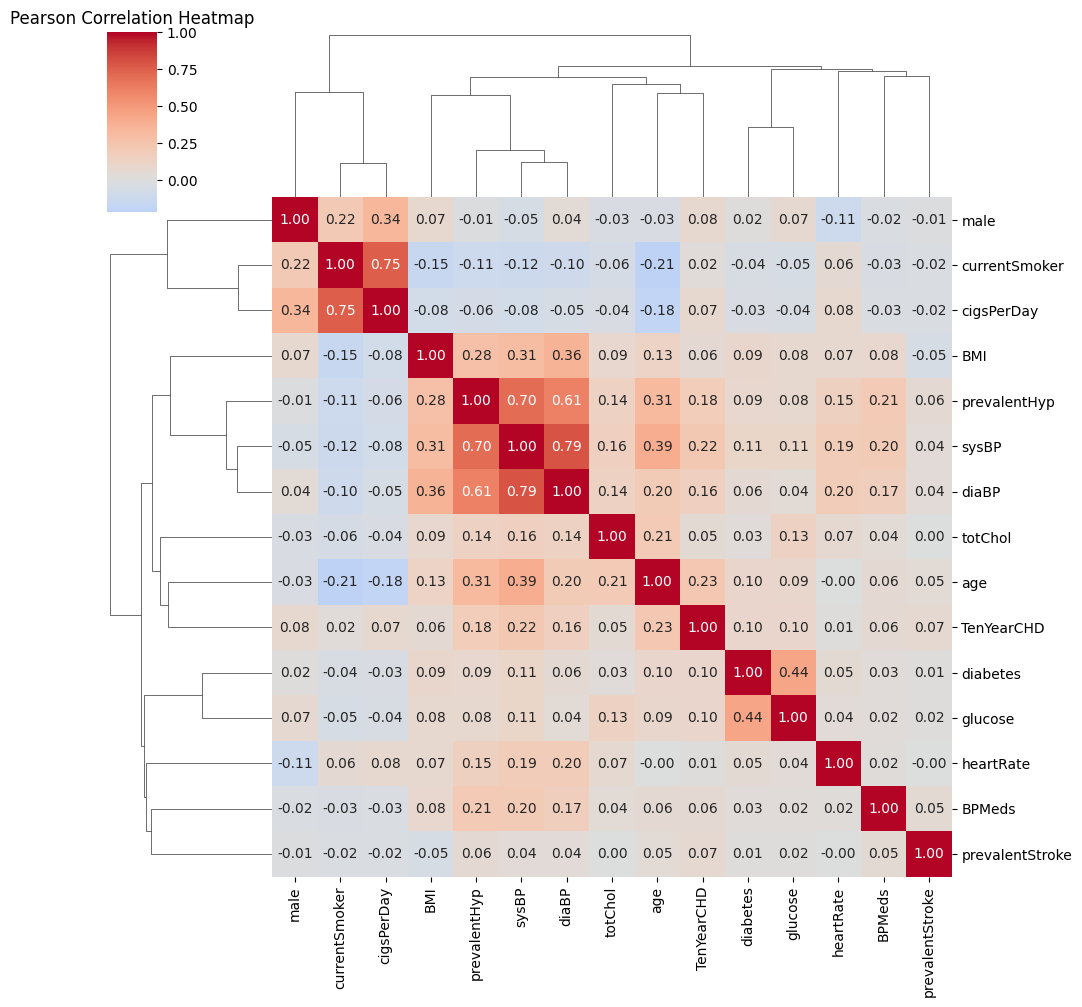

In [24]:
plt.figure(figsize=(10, 8))  # 👈 increase size (width, height)

sns.clustermap(
    train_df.drop(columns=["education"]).corr(method="pearson"),
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)

plt.title("Pearson Correlation Heatmap")
plt.show()

<Figure size 1000x800 with 0 Axes>

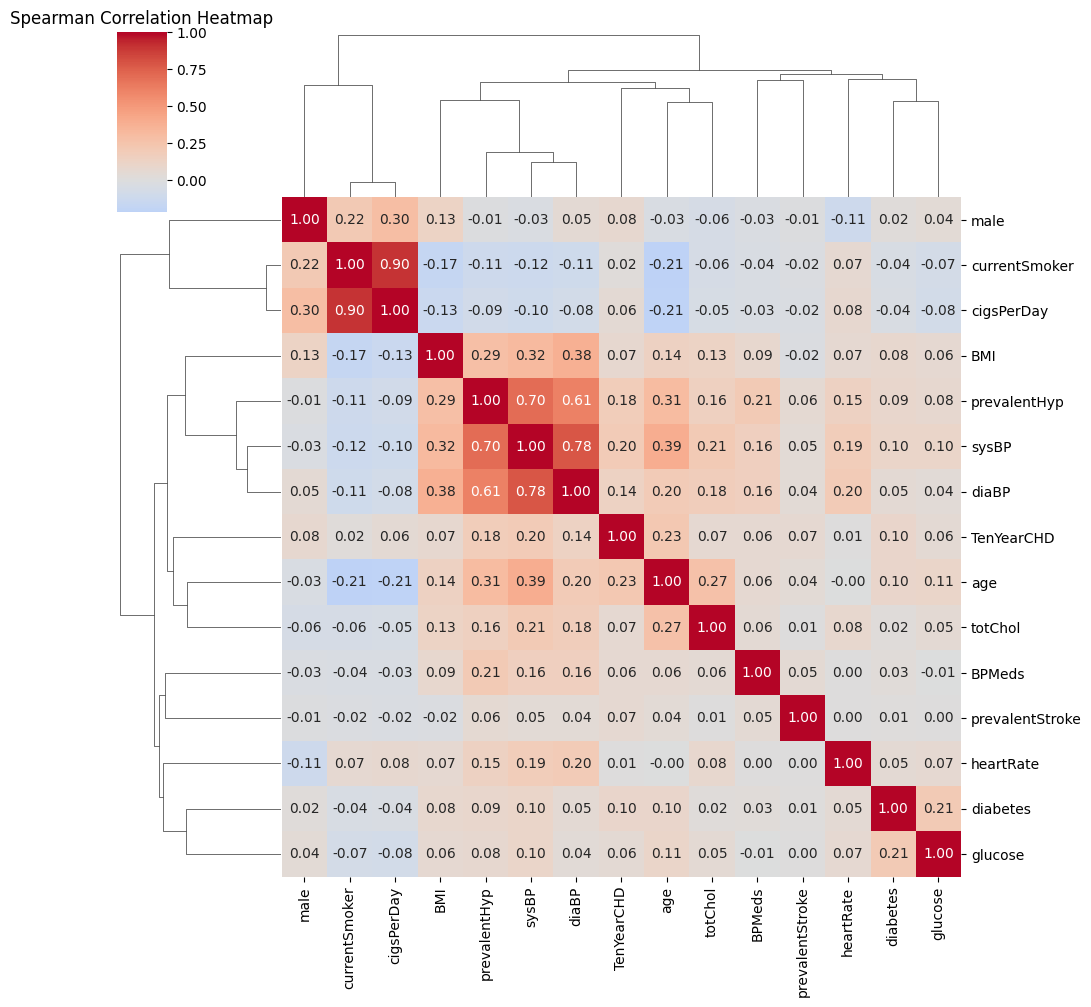

In [25]:
plt.figure(figsize=(10, 8))  # 👈 increase size (width, height)

sns.clustermap(
    train_df.drop(columns=["education"]).corr(method="spearman"),
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)

plt.title("Spearman Correlation Heatmap")
plt.show()

Correlations tells that: <br>
<ul>
    <li>only one of variables currentSmoker and cigsPerDay should be used </li>
    <li>the same for prevalentHyp, sysBP, diaBP</li>
</ul>